# This notebook is used to analyze the output of our new hallucination prompt

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import re

In [ ]:
df = pd.read_csv("Trajectory_New_WithUID.csv")
df["mvk_hallucinations"] = (
    df["mvk_hallucinations"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
)

print(f"Loaded {len(df)} rows.")
print(f"Total hallucinations: {df['mvk_hallucinations'].sum()} ({df['mvk_hallucinations'].mean()*100:.1f}%)")

Loaded 225 rows.
Total hallucinations: 179 (79.6%)


/var/folders/mx/gvdtvwnx1p35qls_6_8glk2r0000gn/T/ipykernel_31762/2043642091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hall_counts.index.map({True:"Hallucination", False:"No Hallucination"}),


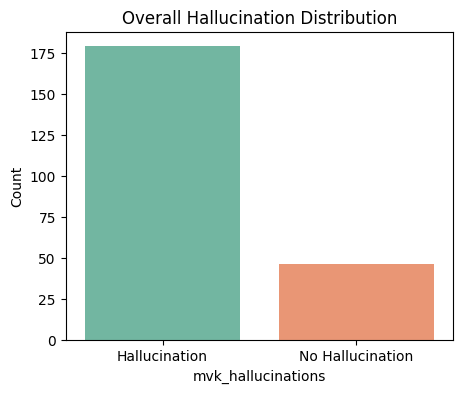

In [ ]:
#Hallucination counts
hall_counts = df["mvk_hallucinations"].value_counts()
plt.figure(figsize=(5,4))
sns.barplot(x=hall_counts.index.map({True:"Hallucination", False:"No Hallucination"}),
            y=hall_counts.values,
            palette="Set2")
plt.title("Overall Hallucination Distribution")
plt.ylabel("Count")
plt.show()


Hallucination Summary by Model:


,Total,Hallucinations,Hallucination_Rate
Model,,,
Model_16,15,15,1.000000
Model_19,42,37,0.880952
Model_17,42,35,0.833333
Model_12,42,33,0.785714
Model_7,42,32,0.761905
Model_6,42,27,0.642857


/var/folders/mx/gvdtvwnx1p35qls_6_8glk2r0000gn/T/ipykernel_31762/3019795253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_summary.reset_index(), x="Model", y="Hallucination_Rate", palette="coolwarm")


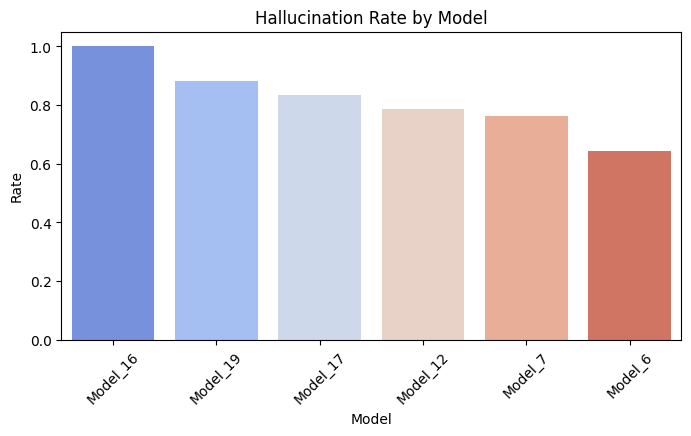

In [ ]:
#Hallucinations by model
df["Model"] = df["UID"].str.extract(r"(Model_\d+)")
model_summary = (
    df.groupby("Model")["mvk_hallucinations"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count":"Total", "sum":"Hallucinations", "mean":"Hallucination_Rate"})
    .sort_values("Hallucination_Rate", ascending=False)
)
print("Hallucination Summary by Model:")
display(model_summary.head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=model_summary.reset_index(), x="Model", y="Hallucination_Rate", palette="coolwarm")
plt.title("Hallucination Rate by Model")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.show()

In [7]:
print(df.columns)

Index(['filename', 'UID', 'id', 'text', 'mvk_hallucinations',
       'mvk_hallucination_location', 'mvk_hallucination_type', 'mvk_rationale',
       'task_1', 'description_1', 'agent_name_1', 'response_1',
       'final_answer_1', 'task_2', 'description_2', 'agent_name_2',
       'response_2', 'final_answer_2', 'task_3', 'description_3',
       'agent_name_3', 'response_3', 'final_answer_3', 'task_4',
       'description_4', 'agent_name_4', 'response_4', 'final_answer_4',
       'task_5', 'description_5', 'agent_name_5', 'response_5',
       'final_answer_5', 'task_6', 'description_6', 'agent_name_6',
       'response_6', 'final_answer_6', 'task_7', 'description_7',
       'agent_name_7', 'response_7', 'final_answer_7', 'task_8',
       'description_8', 'agent_name_8', 'response_8', 'final_answer_8',
       'task_9', 'description_9', 'agent_name_9', 'response_9', 'Model'],
      dtype='object')


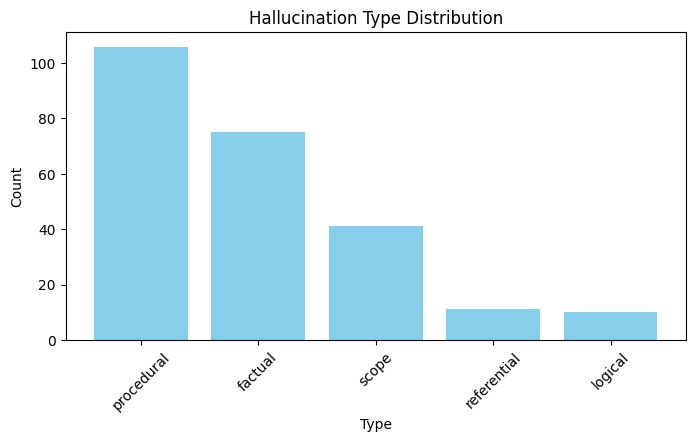

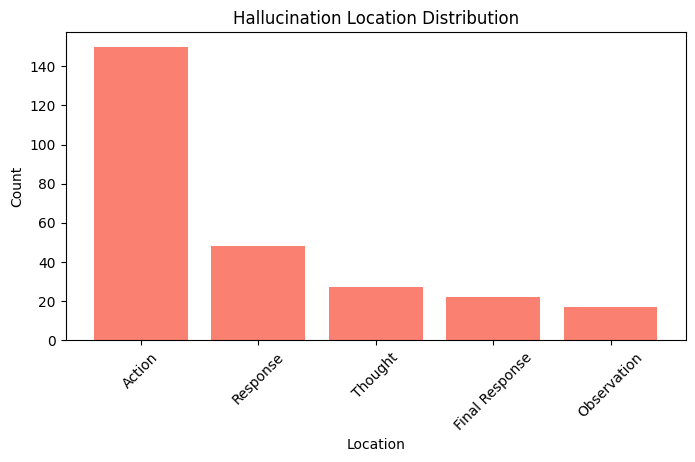

{'total_rows': 225, 'total_hallucinated_rows': 179, 'total_hallucinations_detected': 264, 'unique_hallucination_types': 5, 'unique_hallucination_locations': 5, 'top_5_types': {'procedural': 106, 'factual': 75, 'scope': 41, 'referential': 11, 'logical': 10}, 'top_5_locations': {'Action': 150, 'Response': 48, 'Thought': 27, 'Final Response': 22, 'Observation': 17}}


In [ ]:
#Hallucination type and location
halluc_df = df[df["mvk_hallucinations"].astype(str).str.lower() == "true"].copy()

def clean_type(entry):
    """Clean and standardize hallucination types like ['factual'] -> factual."""
    if pd.isna(entry):
        return []
    entry = str(entry).strip()
    try:
        parsed = ast.literal_eval(entry)
        if isinstance(parsed, list):
            return [str(x).strip().lower() for x in parsed]
        elif isinstance(parsed, str):
            return [parsed.strip().lower()]
    except Exception:
        pass
    return [x.strip().lower() for x in re.split(r"[;,]", entry) if x.strip()]

def clean_location(entry):
    """Extract conceptual hallucination location (Action, Response, etc.)"""
    if pd.isna(entry):
        return []
    entry = str(entry)
    parts = re.split(r"[;]", entry)
    clean_parts = []
    for p in parts:
        match = re.search(
            r"(Observation|Action|Thought|Response|Final Response)",
            p,
            re.IGNORECASE,
        )
        if match:
            clean_parts.append(match.group(1).title())
    return clean_parts

halluc_df["type_list"] = halluc_df["mvk_hallucination_type"].apply(clean_type)
halluc_df["location_list"] = halluc_df["mvk_hallucination_location"].apply(clean_location)

type_exploded = halluc_df.explode("type_list").dropna(subset=["type_list"])
location_exploded = halluc_df.explode("location_list").dropna(subset=["location_list"])

type_counts = type_exploded["type_list"].value_counts().reset_index()
type_counts.columns = ["Type", "Count"]

location_counts = location_exploded["location_list"].value_counts().reset_index()
location_counts.columns = ["Location", "Count"]

type_counts["Count"] = pd.to_numeric(type_counts["Count"], errors="coerce").fillna(0).astype(int)
location_counts["Count"] = pd.to_numeric(location_counts["Count"], errors="coerce").fillna(0).astype(int)

summary = {
    "total_rows": len(df),
    "total_hallucinated_rows": len(halluc_df),
    "total_hallucinations_detected": int(location_counts["Count"].sum()),
    "unique_hallucination_types": len(type_counts),
    "unique_hallucination_locations": len(location_counts),
    "top_5_types": type_counts.head(5).set_index("Type")["Count"].to_dict(),
    "top_5_locations": location_counts.head(5).set_index("Location")["Count"].to_dict(),
}

plt.figure(figsize=(8, 4))
plt.bar(type_counts["Type"], type_counts["Count"], color="skyblue")
plt.title("Hallucination Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(location_counts["Location"], location_counts["Count"], color="salmon")
plt.title("Hallucination Location Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(summary)

Top 10 Task Descriptions Associated with Hallucinations:


task_description
List all failure modes of asset Chiller 6.                                                                                                    18
download asset history for Chiller 9 at MAIN site from 2020-04-27T00:00:00-04:00 to 2020-04-27T23:59:59-04:00                                  8
List all failure modes of Chiller 6 at MAIN site that can be detected by temperature sensors and power input sensors.                          8
download asset history for Chiller 6 at MAIN site from 2020-04-27T00:00:00-04:00 to 2020-04-27T23:59:59-04:00                                  8
List all failure modes of asset Chiller 6 at MAIN site.                                                                                        8
Can you check if there are any anomalies for chiller tonnage, and do you think I should create a work order after reviewing the anomalies?     7
what assets are at site MAIN                                                                                     

/var/folders/mx/gvdtvwnx1p35qls_6_8glk2r0000gn/T/ipykernel_31762/2560973457.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=halluc_task_counts.index, x=halluc_task_counts.values, palette="viridis")


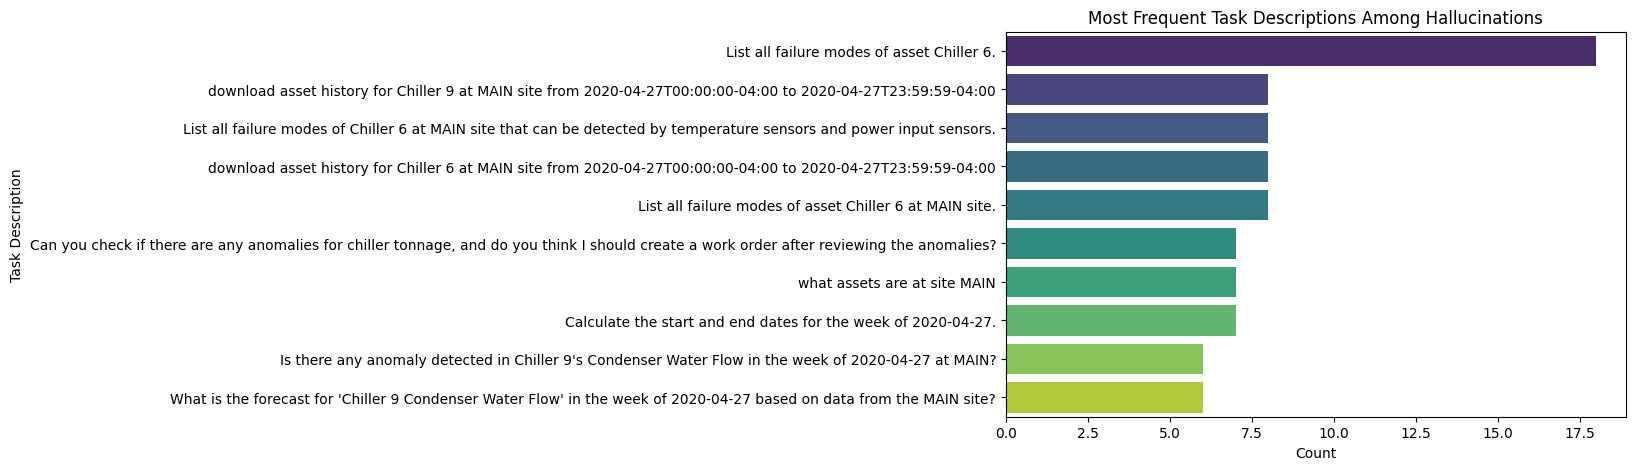

In [ ]:
#Examine where hallucinations occur at the task level

task_cols = [col for col in df.columns if col.startswith("description_")]
if task_cols:
    df_long = df.melt(
        id_vars=["UID", "mvk_hallucinations"],
        value_vars=task_cols,
        var_name="task_num",
        value_name="task_description"
    ).dropna(subset=["task_description"])
    
    halluc_task_counts = (
        df_long[df_long["mvk_hallucinations"] == True]
        .task_description.value_counts()
        .head(10)
    )
    
    print("Top 10 Task Descriptions Associated with Hallucinations:")
    display(halluc_task_counts)

    plt.figure(figsize=(8,5))
    sns.barplot(y=halluc_task_counts.index, x=halluc_task_counts.values, palette="viridis")
    plt.title("Most Frequent Task Descriptions Among Hallucinations")
    plt.xlabel("Count")
    plt.ylabel("Task Description")
    plt.show()